In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0a0a1a'
plt.rcParams['axes.facecolor'] = '#0a0a1a'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

print("✅ Libraries ready!")

✅ Libraries ready!


In [6]:
matches = pd.read_csv('../data/matches.csv')
deliveries = pd.read_csv('../data/deliveries.csv')

print("🏏 Matches dataset:")
print(f"   Rows: {matches.shape[0]}, Columns: {matches.shape[1]}")
print(f"\n🎯 Deliveries dataset:")
print(f"   Rows: {deliveries.shape[0]}, Columns: {deliveries.shape[1]}")
print(f"\n📅 Season range: {matches['season'].min()} to {matches['season'].max()}")
print(f"\n🏟️ Total venues: {matches['venue'].nunique()}")
print(f"👥 Total teams: {matches['team1'].nunique()}")

🏏 Matches dataset:
   Rows: 1095, Columns: 20

🎯 Deliveries dataset:
   Rows: 260920, Columns: 17

📅 Season range: 2007/08 to 2024

🏟️ Total venues: 58
👥 Total teams: 19


In [7]:
# Matches clean karo
matches['date'] = pd.to_datetime(matches['date'])
matches['season'] = matches['season'].astype(str)

# Team names standardize karo (same team alag naam se aati hai)
team_rename = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Punjab Kings': 'Kings XI Punjab',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}

for col in ['team1', 'team2', 'winner', 'toss_winner']:
    matches[col] = matches[col].replace(team_rename)

deliveries['batting_team'] = deliveries['batting_team'].replace(team_rename)
deliveries['bowling_team'] = deliveries['bowling_team'].replace(team_rename)

# Missing values
matches['winner'] = matches['winner'].fillna('No Result')
matches['player_of_match'] = matches['player_of_match'].fillna('N/A')

print("✅ Data clean ho gaya!")
print(f"Total matches: {len(matches)}")
print(f"Total deliveries: {len(deliveries)}")

✅ Data clean ho gaya!
Total matches: 1095
Total deliveries: 260920


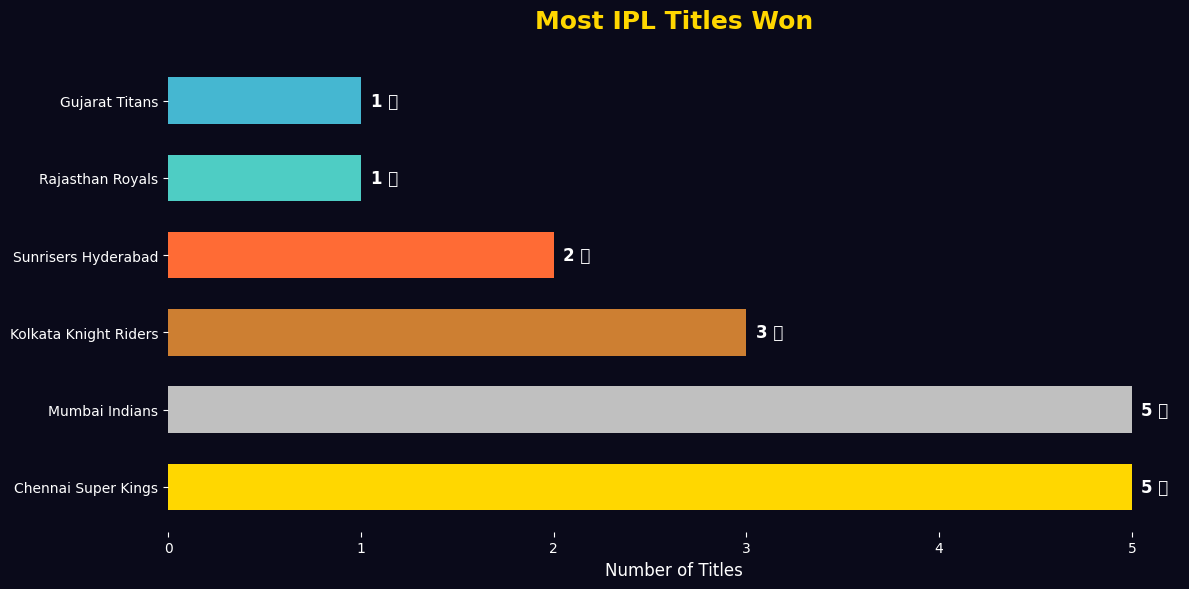

✅ Chart 1 done!


In [9]:
# Sirf finals nikalo
import os

os.makedirs("../visuals", exist_ok=True)
finals = matches[matches['match_type'] == 'Final'] if 'match_type' in matches.columns \
         else matches.groupby('season').last().reset_index()

title_counts = finals['winner'].value_counts().head(8)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#0a0a1a')

colors = ['#FFD700','#C0C0C0','#CD7F32','#FF6B35','#4ECDC4',
          '#45B7D1','#96CEB4','#FFEAA7']

bars = ax.barh(title_counts.index, title_counts.values,
               color=colors[:len(title_counts)], edgecolor='none', height=0.6)

for bar, val in zip(bars, title_counts.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val} 🏆', va='center', fontsize=12, color='white', fontweight='bold')

ax.set_title('Most IPL Titles Won', fontsize=18, fontweight='bold',
             color='#FFD700', pad=20)
ax.set_xlabel('Number of Titles', color='white', fontsize=12)
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig('../visuals/chart1_titles.png', dpi=150, bbox_inches='tight',
            facecolor='#0a0a1a')
plt.show()
print("✅ Chart 1 done!")

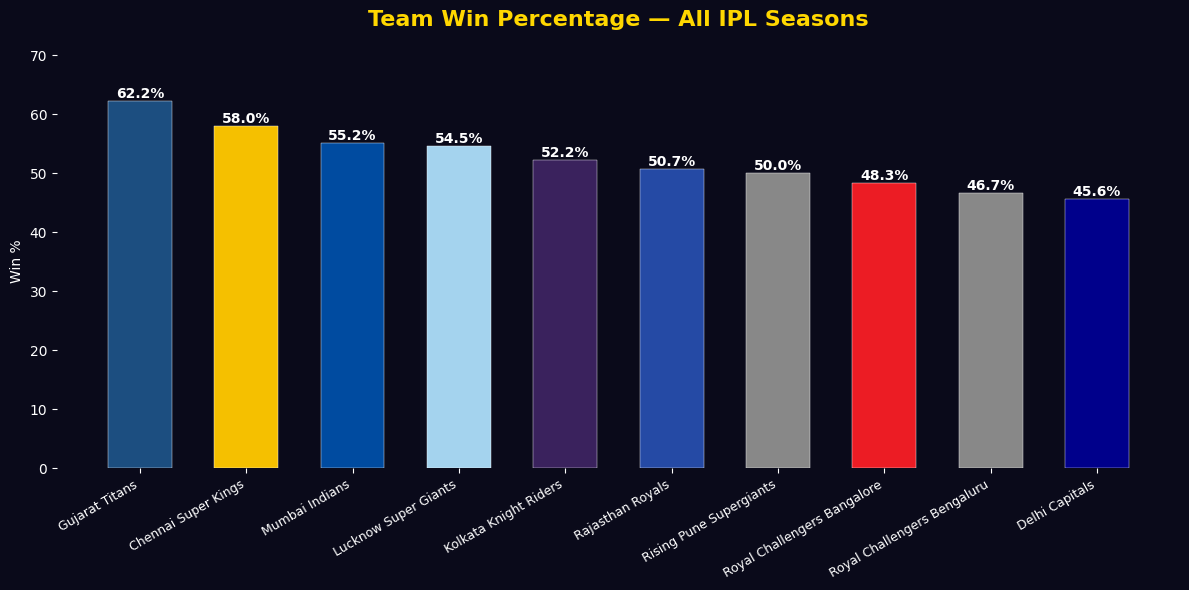

✅ Chart 2 done!


In [10]:
all_teams = pd.concat([matches['team1'], matches['team2']]).value_counts()
wins = matches[matches['winner'] != 'No Result']['winner'].value_counts()

win_pct = (wins / all_teams * 100).dropna().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#0a0a1a')

ipl_colors = {
    'Mumbai Indians': '#004BA0',
    'Chennai Super Kings': '#F5C000',
    'Kolkata Knight Riders': '#3A225D',
    'Royal Challengers Bangalore': '#EC1C24',
    'Sunrisers Hyderabad': '#FF822A',
    'Delhi Capitals': '#00008B',
    'Rajasthan Royals': '#254AA5',
    'Kings XI Punjab': '#DDDDDD',
    'Gujarat Titans': '#1C4E80',
    'Lucknow Super Giants': '#A4D3EE',
}

bar_colors = [ipl_colors.get(t, '#888888') for t in win_pct.index]
bars = ax.bar(win_pct.index, win_pct.values, color=bar_colors,
              edgecolor='white', linewidth=0.3, width=0.6)

for bar, val in zip(bars, win_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10,
            color='white', fontweight='bold')

ax.set_title('Team Win Percentage — All IPL Seasons',
             fontsize=16, fontweight='bold', color='#FFD700', pad=20)
ax.set_ylabel('Win %', color='white')
ax.set_ylim(0, max(win_pct.values) + 8)
plt.xticks(rotation=30, ha='right', fontsize=9)
ax.spines[['top','right','left','bottom']].set_visible(False)
plt.tight_layout()
plt.savefig('../visuals/chart2_win_pct.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a1a')
plt.show()
print("✅ Chart 2 done!")

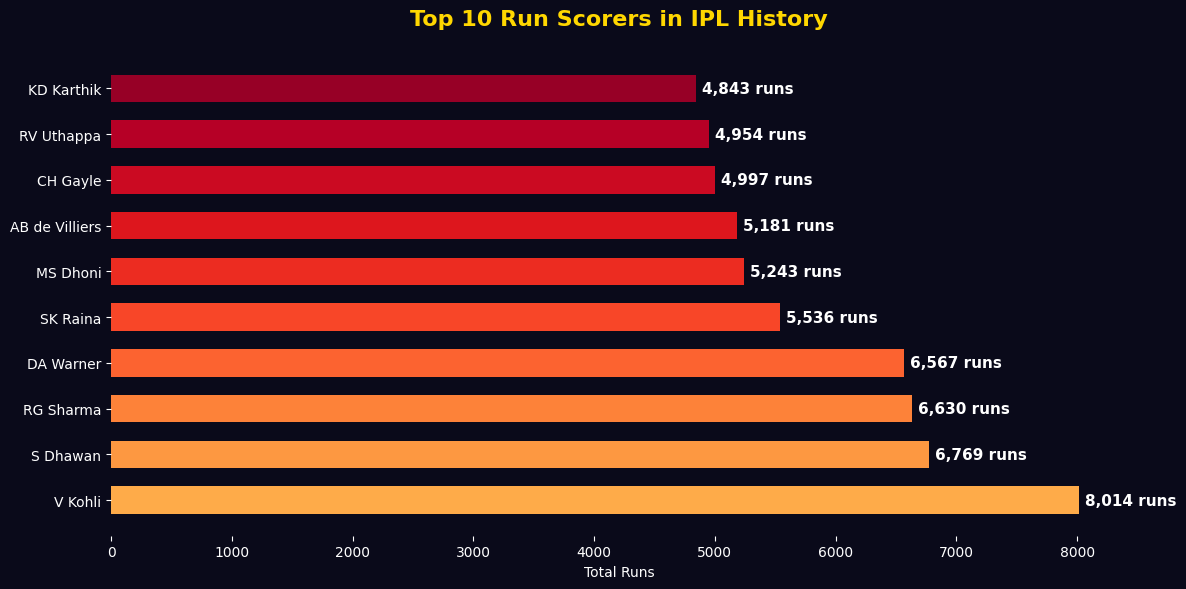

✅ Chart 3 done!


In [11]:
top_batsmen = (deliveries.groupby('batter')['batsman_runs']
               .sum()
               .sort_values(ascending=False)
               .head(10)
               .reset_index())
top_batsmen.columns = ['Player', 'Total Runs']

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#0a0a1a')

gradient_colors = plt.cm.YlOrRd(np.linspace(0.4, 0.95, 10))
bars = ax.barh(top_batsmen['Player'], top_batsmen['Total Runs'],
               color=gradient_colors, edgecolor='none', height=0.6)

for bar, val in zip(bars, top_batsmen['Total Runs']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,} runs', va='center', fontsize=11,
            color='white', fontweight='bold')

ax.set_title('Top 10 Run Scorers in IPL History',
             fontsize=16, fontweight='bold', color='#FFD700', pad=20)
ax.set_xlabel('Total Runs', color='white')
ax.spines[['top','right','left','bottom']].set_visible(False)
plt.tight_layout()
plt.savefig('../visuals/chart3_top_batsmen.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a1a')
plt.show()
print("✅ Chart 3 done!")

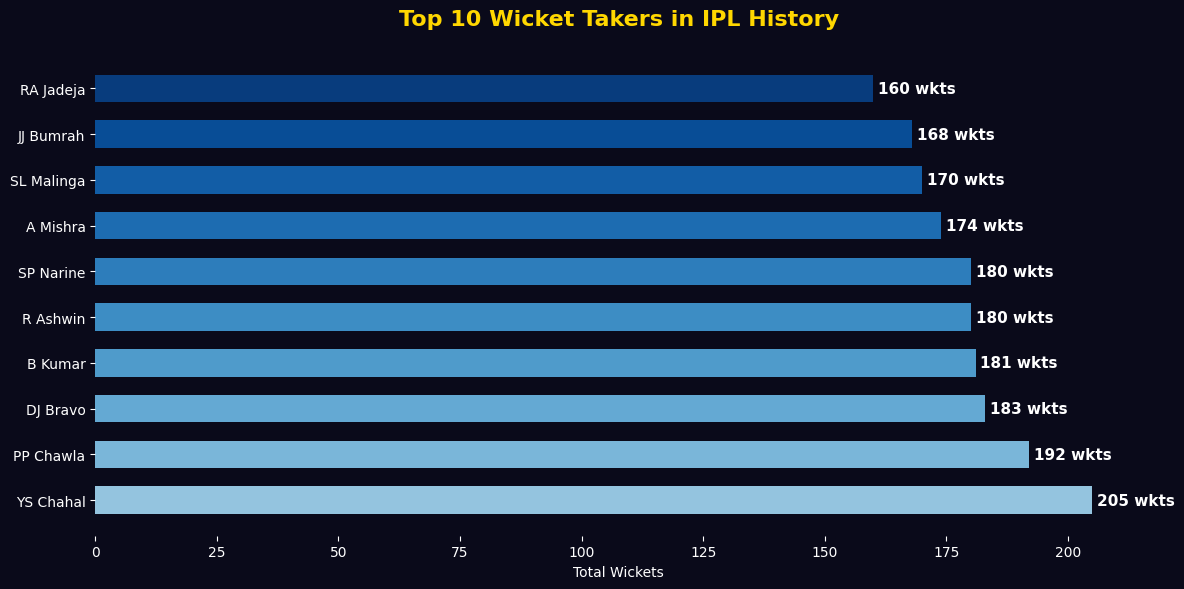

✅ Chart 4 done!


In [12]:
wicket_types = ['caught', 'bowled', 'lbw', 'stumped',
                'caught and bowled', 'hit wicket']

wickets_df = deliveries[deliveries['dismissal_kind'].isin(wicket_types)]
top_bowlers = (wickets_df.groupby('bowler')['dismissal_kind']
               .count()
               .sort_values(ascending=False)
               .head(10)
               .reset_index())
top_bowlers.columns = ['Player', 'Wickets']

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#0a0a1a')

gradient_colors = plt.cm.Blues(np.linspace(0.4, 0.95, 10))
bars = ax.barh(top_bowlers['Player'], top_bowlers['Wickets'],
               color=gradient_colors, edgecolor='none', height=0.6)

for bar, val in zip(bars, top_bowlers['Wickets']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val} wkts', va='center', fontsize=11,
            color='white', fontweight='bold')

ax.set_title('Top 10 Wicket Takers in IPL History',
             fontsize=16, fontweight='bold', color='#FFD700', pad=20)
ax.set_xlabel('Total Wickets', color='white')
ax.spines[['top','right','left','bottom']].set_visible(False)
plt.tight_layout()
plt.savefig('../visuals/chart4_top_bowlers.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a1a')
plt.show()
print("✅ Chart 4 done!")

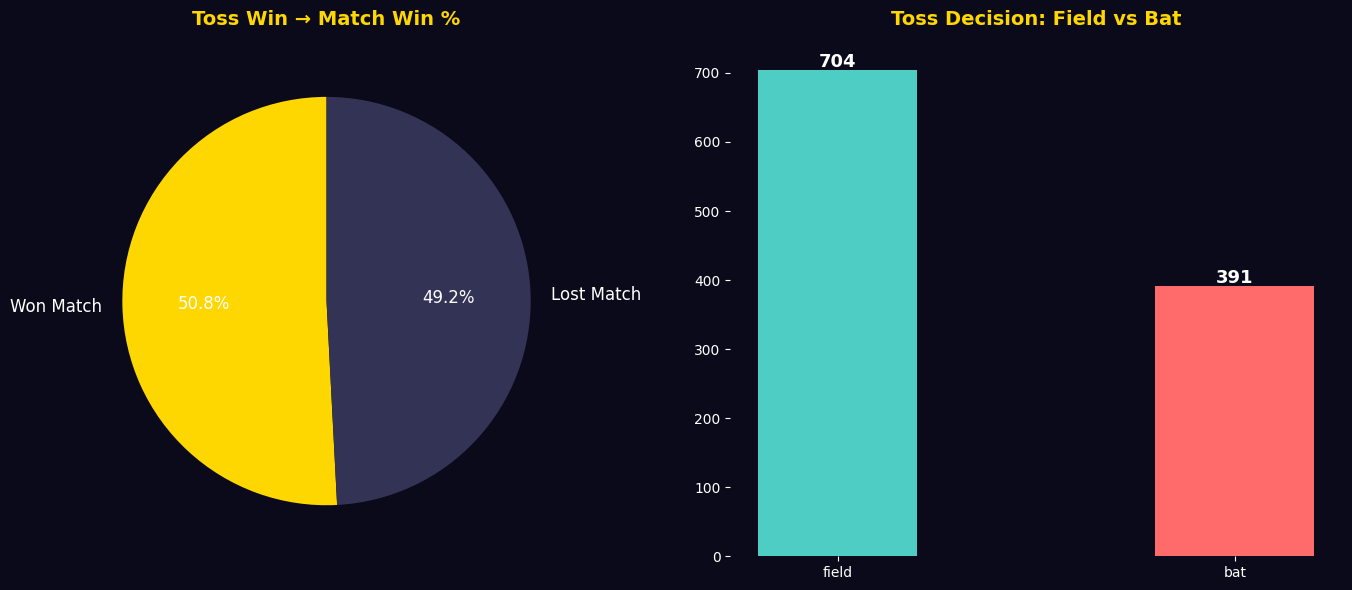

✅ Chart 5 done!


In [13]:
toss_win_match_win = matches[
    (matches['toss_winner'] == matches['winner']) &
    (matches['winner'] != 'No Result')
]
toss_advantage = len(toss_win_match_win) / len(
    matches[matches['winner'] != 'No Result']) * 100

# Toss decision analysis
toss_decision = matches['toss_decision'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0a0a1a')

# Left: Toss win → Match win
ax1 = axes[0]
ax1.set_facecolor('#0a0a1a')
sizes = [toss_advantage, 100 - toss_advantage]
colors_pie = ['#FFD700', '#333355']
wedges, texts, autotexts = ax1.pie(
    sizes, labels=['Won Match', 'Lost Match'],
    autopct='%1.1f%%', colors=colors_pie,
    startangle=90, textprops={'color': 'white', 'fontsize': 12})
ax1.set_title('Toss Win → Match Win %',
              fontsize=14, fontweight='bold', color='#FFD700', pad=15)

# Right: Field vs Bat decision
ax2 = axes[1]
ax2.set_facecolor('#0a0a1a')
bars = ax2.bar(toss_decision.index, toss_decision.values,
               color=['#4ECDC4', '#FF6B6B'], edgecolor='none', width=0.4)
for bar, val in zip(bars, toss_decision.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=13,
             color='white', fontweight='bold')
ax2.set_title('Toss Decision: Field vs Bat',
              fontsize=14, fontweight='bold', color='#FFD700', pad=15)
ax2.spines[['top','right','left','bottom']].set_visible(False)
ax2.tick_params(colors='white')

plt.tight_layout()
plt.savefig('../visuals/chart5_toss.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a1a')
plt.show()
print("✅ Chart 5 done!")

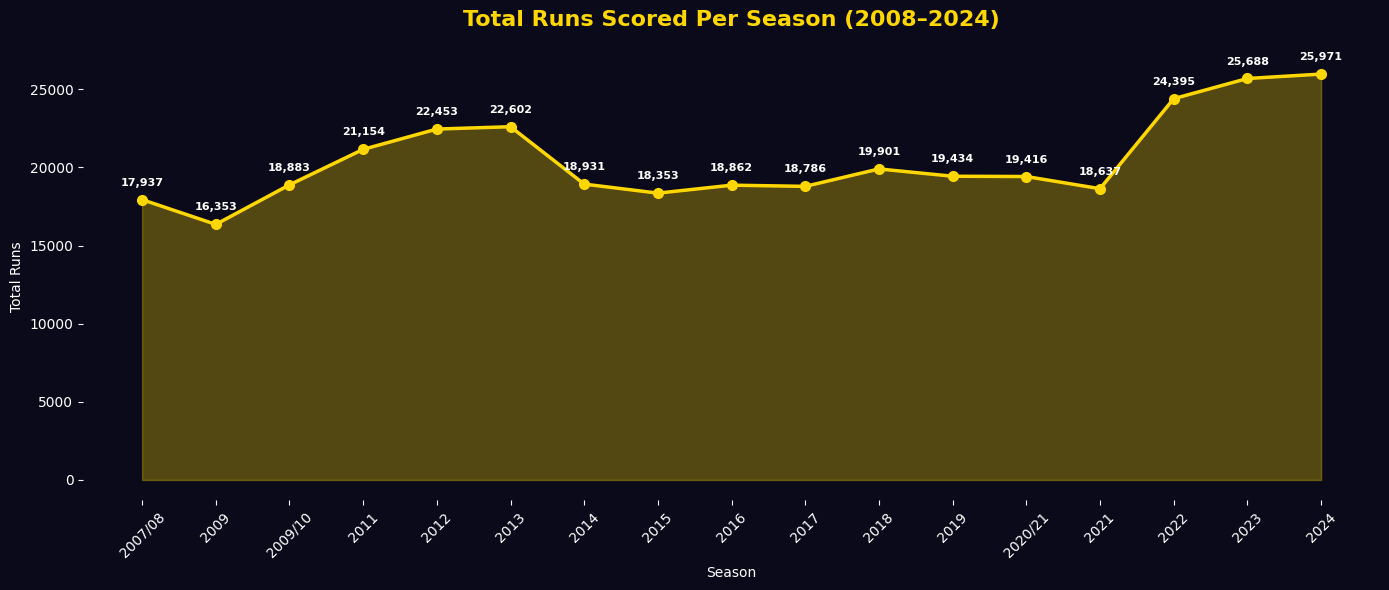

✅ Chart 6 done!


In [14]:
season_runs = (deliveries.merge(
    matches[['id', 'season']], left_on='match_id', right_on='id')
    .groupby('season')['total_runs']
    .sum()
    .reset_index()
    .sort_values('season'))

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#0a0a1a')

ax.fill_between(season_runs['season'], season_runs['total_runs'],
                alpha=0.3, color='#FFD700')
ax.plot(season_runs['season'], season_runs['total_runs'],
        color='#FFD700', linewidth=2.5, marker='o', markersize=7)

for x, y in zip(season_runs['season'], season_runs['total_runs']):
    ax.annotate(f'{y:,}', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8,
                color='white', fontweight='bold')

ax.set_title('Total Runs Scored Per Season (2008–2024)',
             fontsize=16, fontweight='bold', color='#FFD700', pad=20)
ax.set_ylabel('Total Runs', color='white')
ax.set_xlabel('Season', color='white')
plt.xticks(rotation=45)
ax.spines[['top','right','left','bottom']].set_visible(False)
plt.tight_layout()
plt.savefig('../visuals/chart6_season_runs.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a1a')
plt.show()
print("✅ Chart 6 done!")

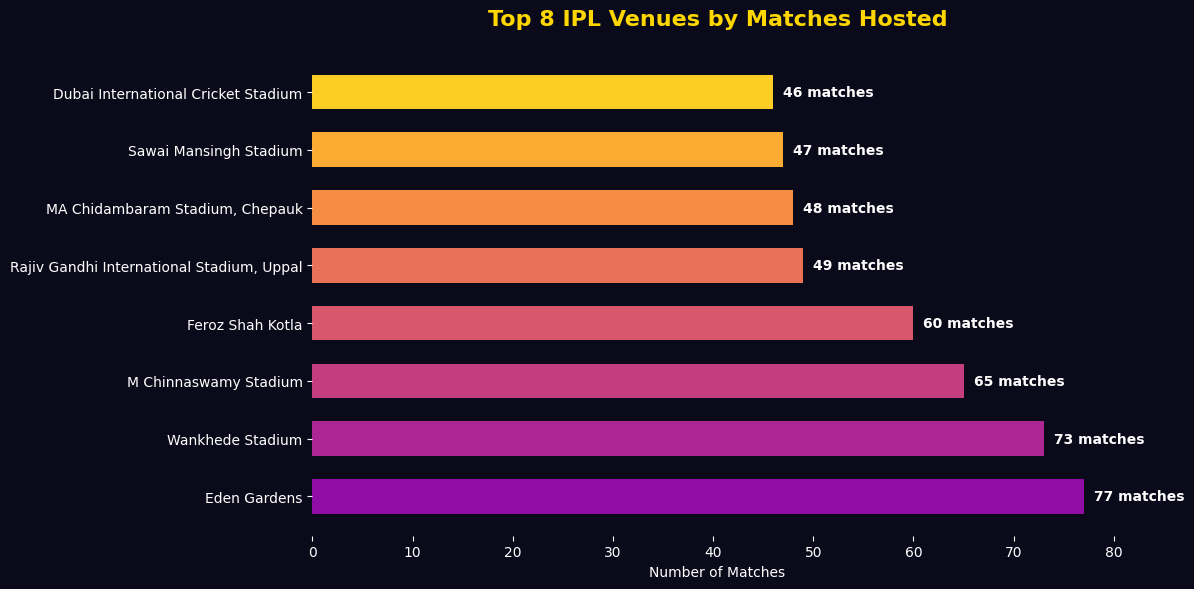

✅ Chart 7 done!


In [15]:
top_venues = matches['venue'].value_counts().head(8)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#0a0a1a')

colors = plt.cm.plasma(np.linspace(0.3, 0.9, 8))
bars = ax.barh(top_venues.index, top_venues.values,
               color=colors, edgecolor='none', height=0.6)

for bar, val in zip(bars, top_venues.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val} matches', va='center',
            fontsize=10, color='white', fontweight='bold')

ax.set_title('Top 8 IPL Venues by Matches Hosted',
             fontsize=16, fontweight='bold', color='#FFD700', pad=20)
ax.set_xlabel('Number of Matches', color='white')
ax.spines[['top','right','left','bottom']].set_visible(False)
plt.tight_layout()
plt.savefig('../visuals/chart7_venues.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a1a')
plt.show()
print("✅ Chart 7 done!")

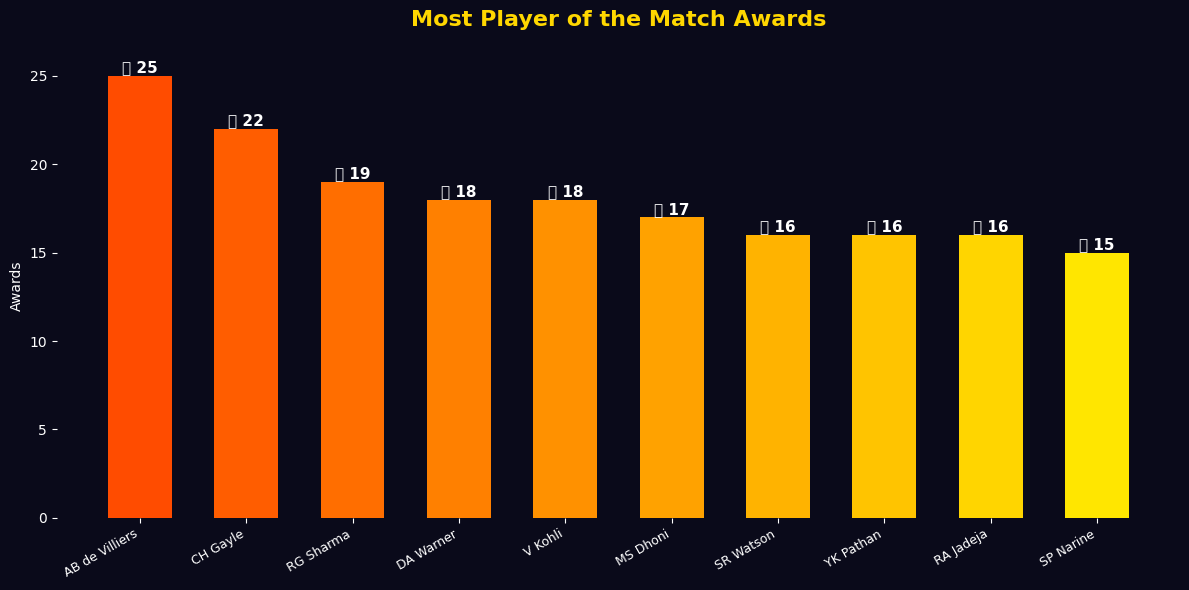

✅ Chart 8 done!


In [16]:
potm = (matches[matches['player_of_match'] != 'N/A']
        ['player_of_match']
        .value_counts()
        .head(10))

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#0a0a1a')

colors = plt.cm.autumn(np.linspace(0.3, 0.9, 10))
bars = ax.bar(potm.index, potm.values,
              color=colors, edgecolor='none', width=0.6)

for bar, val in zip(bars, potm.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2, f'⭐ {val}',
            ha='center', fontsize=11,
            color='white', fontweight='bold')

ax.set_title('Most Player of the Match Awards',
             fontsize=16, fontweight='bold', color='#FFD700', pad=20)
ax.set_ylabel('Awards', color='white')
plt.xticks(rotation=30, ha='right', fontsize=9)
ax.spines[['top','right','left','bottom']].set_visible(False)
plt.tight_layout()
plt.savefig('../visuals/chart8_potm.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a1a')
plt.show()
print("✅ Chart 8 done!")

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Features select karo
features = matches[['team1', 'team2', 'toss_winner',
                     'toss_decision', 'venue', 'winner']].copy()
features = features[features['winner'] != 'No Result'].dropna()

# Label Encoding
le_dict = {}
for col in ['team1', 'team2', 'toss_winner',
            'toss_decision', 'venue', 'winner']:
    le = LabelEncoder()
    features[col] = le.fit_transform(features[col])
    le_dict[col] = le

X = features[['team1', 'team2', 'toss_winner', 'toss_decision', 'venue']]
y = features['winner']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Model train karo
model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

acc = accuracy_score(y_test, predictions) * 100
print(f"🎯 Match Prediction Accuracy: {acc:.2f}%")
print("\n📊 Detailed Report:")
print(classification_report(y_test, predictions, zero_division=0))

🎯 Match Prediction Accuracy: 49.54%

📊 Detailed Report:
              precision    recall  f1-score   support

           0       0.66      0.62      0.64        37
           1       0.31      0.25      0.28        20
           2       0.75      0.60      0.67         5
           3       0.50      0.11      0.18         9
           4       0.43      0.50      0.47        20
           5       0.00      0.00      0.00         2
           6       0.50      0.52      0.51        23
           7       0.40      0.67      0.50         3
           8       0.48      0.54      0.51        26
           9       0.50      0.33      0.40         3
          10       0.62      0.60      0.61        25
          11       0.50      0.25      0.33         4
          12       0.42      0.42      0.42        26
          13       0.00      0.00      0.00         2
          14       0.40      0.77      0.53        13

    accuracy                           0.50       218
   macro avg       0.43 

In [19]:
# Top batsmen
top_bat = (deliveries.groupby('batter')['batsman_runs']
           .agg(['sum', 'count'])
           .reset_index())
top_bat.columns = ['Player', 'Total Runs', 'Balls Faced']
top_bat['Strike Rate'] = (top_bat['Total Runs'] /
                           top_bat['Balls Faced'] * 100).round(2)
top_bat = top_bat.sort_values('Total Runs', ascending=False).head(20)

# Top bowlers
wicket_types = ['caught', 'bowled', 'lbw', 'stumped',
                'caught and bowled', 'hit wicket']
top_bowl = (deliveries[deliveries['dismissal_kind'].isin(wicket_types)]
            .groupby('bowler')['dismissal_kind']
            .count()
            .reset_index()
            .rename(columns={'bowler': 'Player',
                             'dismissal_kind': 'Wickets'})
            .sort_values('Wickets', ascending=False)
            .head(20))

# Team summary
team_wins = matches[matches['winner'] != 'No Result']['winner'].value_counts()
team_played = pd.concat([matches['team1'],
                          matches['team2']]).value_counts()
team_summary = pd.DataFrame({
    'Team': team_wins.index,
    'Matches Won': team_wins.values,
    'Matches Played': [team_played.get(t, 0) for t in team_wins.index]
})
team_summary['Win %'] = (team_summary['Matches Won'] /
                          team_summary['Matches Played'] * 100).round(2)

# Excel save karo
import os

os.makedirs("../report", exist_ok=True)
with pd.ExcelWriter('../report/IPL_Report.xlsx',
                    engine='openpyxl') as writer:
    top_bat.to_excel(writer, sheet_name='Top Batsmen', index=False)
    top_bowl.to_excel(writer, sheet_name='Top Bowlers', index=False)
    team_summary.to_excel(writer, sheet_name='Team Summary', index=False)
    matches.to_excel(writer, sheet_name='All Matches', index=False)

print("✅ Excel report save ho gaya: report/IPL_Report.xlsx")

✅ Excel report save ho gaya: report/IPL_Report.xlsx
